In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split


In [1309]:
#Rename columns
df = pd.read_csv("merged.csv")
df = df.replace({np.nan: "None"})
df.rename(columns={"Timestamp": "time", "I come to lecture:": "attendance", "I've had prior machine learning / data science experience": "experience",
                  "Which section are you in?": "section", "About how long, in hours, did you study for exam 1?": "study_time", 
                  "What year are you?": "year", "Did you do the readings?": "readings", "How many hours a day on average do you spend on sites with infinite scroll?":
                  "scrolling", "How many hours of sleep did you get the night before the exam?": "sleep", "Did you leave the exam early?": "left_early",
                  "What grade do you think you got?": "predicted_grade", "Total Score": "score"}, inplace=True)


#Unrelated features
df.drop("Unnamed: 0", axis=1, inplace=True) 
df.drop("time", axis=1, inplace=True)
df.drop("I wanted the extra credit but just put down random responses (you'll still get the extra credit if you say yes)", axis=1, inplace=True)
df.drop("Max Points", axis=1, inplace=True)

df = df[df["readings"] != "I don't want to respond"]
df = df[df["predicted_grade"] != "Prefer not to say"]
df = df[df["year"] != "It's complicated"]
df.head()




,attendance,experience,section,study_time,year,readings,scrolling,sleep,left_early,predicted_grade,score
0,Always,None,None,9.0,Junior,Some of them,6.0,7.0,Yes,D,42.3
1,Always,None,None,6.0,Junior,Some of them,0.0,5.0,No,D,21.4
2,Always,None,None,5.0,Junior,Some of them,2.0,7.0,No,B,51.5
3,Always,None,None,6.0,Junior,All of them,0.0,8.0,No,B,52.4
4,Always,Quite a bit,None,3.0,Junior,Some of them,3.0,3.0,No,C,49.5


In [1310]:
df["section"].value_counts()

section
2:00pm    83
9:30am    50
None      34
Name: count, dtype: int64

In [1311]:
group1 = df[df["section"] == "9:30am"]["score"]
group2 = df[df["section"] == "2:00pm"]["score"]

section_test = f_oneway(group1, group2)
print("Section p-val", section_test[1], "\n")

group1 = df[df["year"] == "Sophomore"]["score"]
group2 = df[df["year"] == "Junior"]["score"]
group3 = df[df["year"] == "Senior"]["score"]

year_test = f_oneway(group1, group2)
print("Sophomore vs Junior", year_test[1])

year_test = f_oneway(group1, group3)
print("Sophomore vs Senior", year_test[1])

year_test = f_oneway(group2, group3)
print("Junior vs Senior", year_test[1])


Section p-val 0.13389815213677464 

Sophomore vs Junior 4.4549928110086163e-05
Sophomore vs Senior 0.0036112506920011104
Junior vs Senior 0.9934241271964249


In [1312]:
#Year category is almost 75% junior, too much imbalance
df.drop("year", axis=1, inplace=True)

#Section has many null values, not likely a significant factor
df.drop("section", axis=1, inplace=True)


In [1313]:
#Converting categorical to numerical
df["attendance"].unique()
map = {"Basically never": 0, "Less than half the time": 1, "More than half the time": 2, "Always": 3}
df["attendance"] = df["attendance"].map(map)

df["experience"].unique()
map = {"None" : 0, "Some": 1, "Quite a bit": 2}
df["experience"] = df["experience"].map(map)

df["readings"].unique()
map = {"None of them": 0, "Some of them": 1, "All of them": 2}
df["readings"] = df["readings"].map(map)

df["predicted_grade"].unique()
grade_map = {"F": 1, "D": 2, "C": 3, "B": 4, "A": 5}
df["predicted_grade"] = df["predicted_grade"].map(grade_map)

df["left_early"] = df["left_early"].map({"No": False, "Yes": True})

df.head()

,attendance,experience,study_time,readings,scrolling,sleep,left_early,predicted_grade,score
0,3,0,9.0,1,6.0,7.0,True,2,42.3
1,3,0,6.0,1,0.0,5.0,False,2,21.4
2,3,0,5.0,1,2.0,7.0,False,4,51.5
3,3,0,6.0,2,0.0,8.0,False,4,52.4
4,3,2,3.0,1,3.0,3.0,False,3,49.5


In [1314]:
#Normalize the features
fields = ["study_time", "scrolling", "sleep"]
df[fields] = (df[fields] - df[fields].min()) / (df[fields].max() - df[fields].min())
df.head()

,attendance,experience,study_time,readings,scrolling,sleep,left_early,predicted_grade,score
0,3,0,0.170213,1,0.545455,0.7,True,2,42.3
1,3,0,0.106383,1,0.000000,0.5,False,2,21.4
2,3,0,0.085106,1,0.181818,0.7,False,4,51.5
3,3,0,0.106383,2,0.000000,0.8,False,4,52.4
4,3,2,0.042553,1,0.272727,0.3,False,3,49.5


In [1315]:
#Binning

def convert_letter(score):
    if score/65.0 >= 0.9: return 'A'
    elif score/65.0 >= 0.8: return 'B'
    elif score/65.0 >= 0.7: return 'C'
    elif score/65.0 >= 0.6: return 'D'
    else: return 'F'

df["letter_grade"] = df["score"].apply(convert_letter)
df["letter_grade_num"] = df["letter_grade"].map(grade_map)

df["passed"] = df["score"].apply(lambda x: x >= 45.5)
df.head()



,attendance,experience,study_time,readings,scrolling,sleep,left_early,predicted_grade,score,letter_grade,letter_grade_num,passed
0,3,0,0.170213,1,0.545455,0.7,True,2,42.3,D,2,False
1,3,0,0.106383,1,0.000000,0.5,False,2,21.4,F,1,False
2,3,0,0.085106,1,0.181818,0.7,False,4,51.5,C,3,True
3,3,0,0.106383,2,0.000000,0.8,False,4,52.4,B,4,True
4,3,2,0.042553,1,0.272727,0.3,False,3,49.5,C,3,True


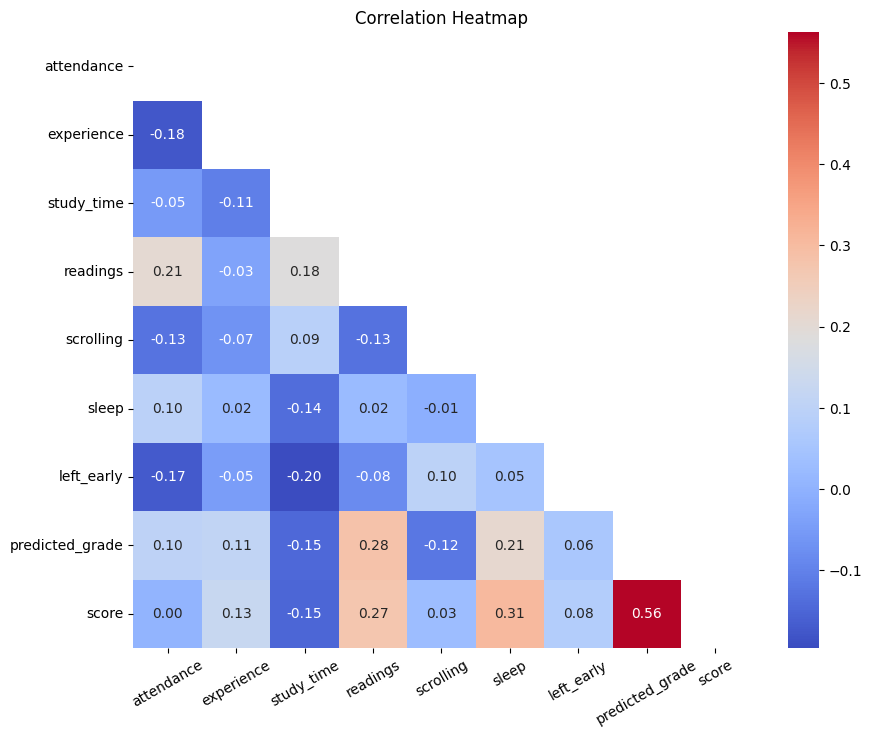

In [1316]:
plt.figure(figsize=(10,8))
feature_df = df.iloc[:, 0:9]

corr_matrix = feature_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    square=True,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=30)
plt.show()

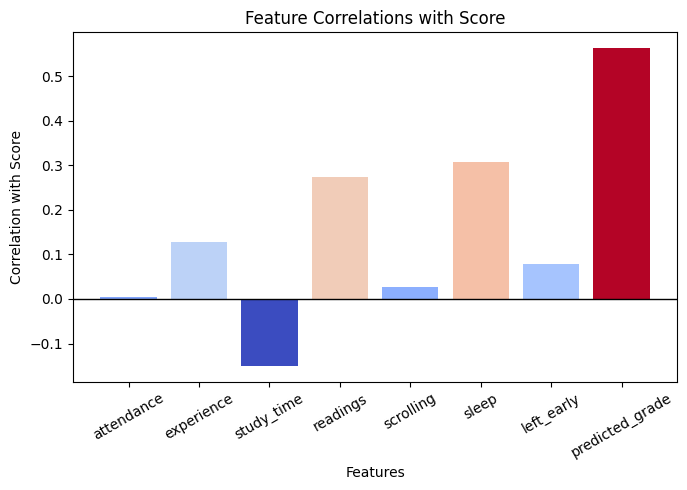

In [1317]:
import matplotlib.cm as cm

# List your feature names here
features = ["attendance", "experience", "study_time", "readings", "scrolling", "sleep", "left_early", "predicted_grade"]

# Compute correlations with score
corr_values = [df[f].corr(df["score"]) for f in features]
corr_values = np.array(corr_values)
norm = plt.Normalize(corr_values.min(), corr_values.max())
colors = cm.coolwarm(norm(corr_values))

plt.figure(figsize=(7, 5))
plt.bar(features, corr_values, color=colors)
plt.xlabel("Features")
plt.ylabel("Correlation with Score")
plt.title("Feature Correlations with Score")
plt.xticks(rotation=30)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [1318]:
regression_df = df.copy()

df.drop("attendance", axis=1, inplace=True)
df.drop("scrolling", axis=1, inplace=True)
df.drop("left_early", axis=1, inplace=True)

df.head()
df["passed"].value_counts()

passed
False    96
True     71
Name: count, dtype: int64

In [1319]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

X = df.iloc[:, 0:5]
Y = df["passed"]

params = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, params, cv=10)
grid.fit(X, Y)

print(grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}


In [ ]:
#Passed/Failed
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score

X = df.iloc[:, 0:5]
Y = df["passed"]
 
model = knn(n_neighbors=11, metric="euclidean", weights="uniform")
y_pred_cv = cross_val_predict(model, X, Y, cv=10)

knn_accuracy = accuracy_score(Y, y_pred_cv)
knn_precision = precision_score(Y, y_pred_cv)
knn_recall = recall_score(Y, y_pred_cv)

print("Accuracy:", knn_accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels={"Passed", "Failed"})
display.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

X = df.iloc[:, 0:5]
Y = df["passed"]

params = {
    "C": [0.1, 1, 5, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

svm = svm.SVC()
grid = GridSearchCV(svm, params, cv=10)
grid.fit(X, Y)

print("Best params:", grid.best_params_)

In [ ]:
#Passed/Failed
from sklearn import svm
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

model = svm.SVC(kernel="linear", gamma="scale", C=1)
y_pred_cv = cross_val_predict(model, X, Y, cv=10)

svm_accuracy = accuracy_score(Y, y_pred_cv)
svm_precision = precision_score(Y, y_pred_cv)
svm_recall = recall_score(Y, y_pred_cv)

print("Accuracy:", svm_accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels={"Passed", "Failed"})
display.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [1, 5, 10, 15, 20]
}

X = df.iloc[:, 0:5]
Y = df["passed"]
 

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=10,
    n_jobs=-17
)

grid.fit(X, Y)

print("Best params:", grid.best_params_)

In [ ]:
#Passed/Failed
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

X = df.iloc[:, 0:5]
Y = df["passed"]

model = rf(n_estimators=200, max_depth = 5)
y_pred_cv = cross_val_predict(model, X, Y, cv=10)

rf_accuracy = accuracy_score(Y, y_pred_cv)
rf_precision = precision_score(Y, y_pred_cv)
rf_recall = recall_score(Y, y_pred_cv)

print("Accuracy:", rf_accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels={"Passed", "Failed"})
display.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")

In [ ]:
accuracies = [knn_accuracy, svm_accuracy, rf_accuracy]
precisions = [knn_precision, svm_precision, rf_precision]
recalls = [knn_recall, svm_recall, rf_recall]

models = ["KNN", "SVM", "RF"]
x = np.arange(len(models))
width = 0.22

plt.figure(figsize=(10, 6))


plt.bar(x - width, accuracies, width, label='Accuracy', color="#3B8F56")
plt.bar(x, precisions, width, label='Precision', color="#497A8F")
plt.bar(x + width, recalls, width, label='Recall', color="#754A53")

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Comparison: Accuracy, Precision, Recall")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

X = df.iloc[:, 0:5]
Y = df["letter_grade"]

params = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, params, cv=5)
grid.fit(X, Y)

print(grid.best_params_)

In [ ]:
#Letter Grade
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

X = df.iloc[:, 0:5]
Y = df["letter_grade"]
 
model = knn(n_neighbors=11, metric="euclidean", weights="distance")
y_pred_cv = cross_val_predict(model, X, Y, cv=5)
accuracy = accuracy_score(Y, y_pred_cv)

print("Accuracy:", accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels=["A", "B", "C", "D", "F"])
display.plot(cmap="crest")
plt.title("KNN Confusion Matrix")


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [1, 5, 10, 15, 20]
}

X = df.iloc[:, 0:5]
Y = df["letter_grade"]
 

rf = RandomForestClassifier()

grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    n_jobs=-17
)

grid.fit(X, Y)

print("Best params:", grid.best_params_)

In [ ]:
#Letter Grade
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

X = df.iloc[:, 0:5]
Y = df["letter_grade"]
 
model = rf(n_estimators=200, max_depth = 3)
y_pred_cv = cross_val_predict(model, X, Y, cv=5)
accuracy = accuracy_score(Y, y_pred_cv)

print("Accuracy:", accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels=["A", "B", "C", "D", "F"])
display.plot(cmap="crest")
plt.title("Random Forest Confusion Matrix")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

X = df.iloc[:, 0:5]
Y = df["letter_grade"]

params = {
    "C": [0.1, 1, 5, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

svm = svm.SVC()
grid = GridSearchCV(svm, params, cv=5)
grid.fit(X, Y)

print("Best params:", grid.best_params_)

In [ ]:
#Letter Grade
from sklearn.model_selection import cross_val_predict
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

X = df.iloc[:, 0:5]
Y = df["letter_grade"]
 
model = svm.SVC(kernel="linear", C=5, gamma="scale")
y_pred_cv = cross_val_predict(model, X, Y, cv=5)
accuracy = accuracy_score(Y, y_pred_cv)

print("Accuracy:", accuracy)

matrix = confusion_matrix(Y, y_pred_cv)
display = ConfusionMatrixDisplay(confusion_matrix= matrix, display_labels=["A", "B", "C", "D", "4F"])
display.plot(cmap="crest")
plt.title("SVM Confusion Matrix")

In [1353]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline

X = regression_df.iloc[:, 0:8]
Y = df["score"]

# 10-fold CV (shuffled)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: scale -> ridge
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.1)
)

# Get cross-validated predictions for every sample
y_pred_cv = cross_val_predict(model, X, Y, cv=cv)

# Metrics computed on all data vs CV predictions
rmse = root_mean_squared_error(Y, y_pred_cv)
mae = mean_absolute_error(Y, y_pred_cv)
r2 = r2_score(Y, y_pred_cv)

print(f"RMSE (10-fold CV):  {rmse:.3f}")
print(f"MAE (10-fold CV):   {mae:.3f}")
print(f"R² (10-fold CV):    {r2:.3f}")


RMSE (10-fold CV):  8.007
MAE (10-fold CV):   6.259
R² (10-fold CV):    0.328


In [ ]:
#Plotting residuals
plt.scatter(y_test, y_test - y_pred)
plt.axhline(0, color="red")
plt.xlabel("True Score")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores (Linear Regression)")

# 45-degree reference line
min_val = min(Y.min(), y_pred.min())
max_val = max(Y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.tight_layout()
plt.show()